In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns 
import matplotlib.ticker as mtick 
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Customer-Churn.csv')

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape


(7043, 21)

In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Text(0.5, 0, 'count')

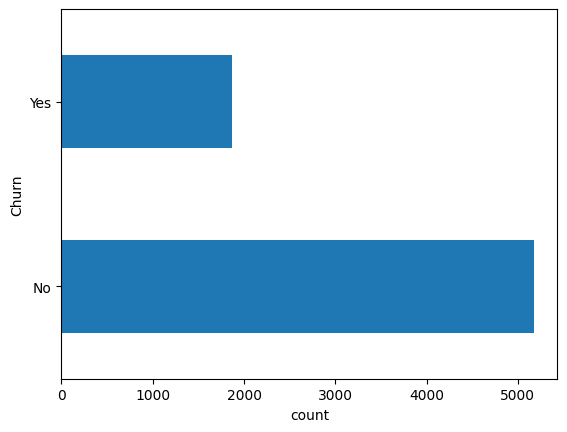

In [8]:
df['Churn'].value_counts().plot(kind = 'barh')
plt.xlabel("count")

AttributeError: module 'matplotlib.pyplot' has no attribute 'ylable'

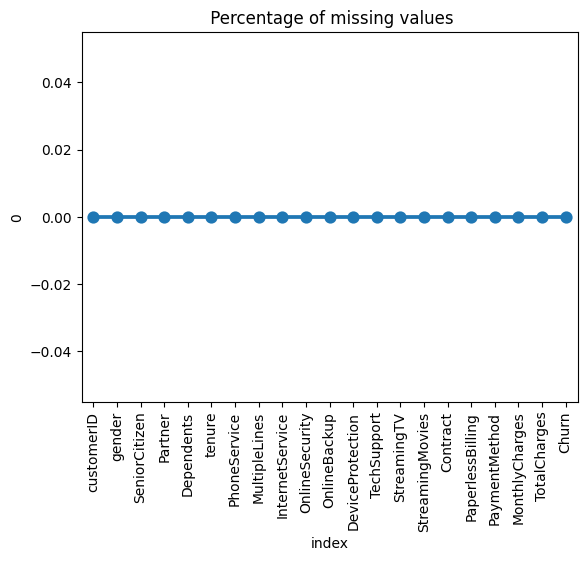

In [9]:
missing = pd.DataFrame((df.isnull().sum())*100/df.shape[0]).reset_index()
sns.pointplot(x ='index' , y = 0 , data = missing )
plt.xticks(rotation = 90)
plt.title(" Percentage of missing values")
plt.ylable("percentage")
plt.show()

In [11]:
new_df =df.copy()

In [12]:
new_df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
new_df.TotalCharges = pd.to_numeric(new_df.TotalCharges,errors='coerce')

In [14]:
new_df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [15]:
new_df.dropna(how='any', inplace=True)

In [16]:
print(new_df['tenure'].max())

72


In [17]:
labels = ["{0}-{1}".format(i,i+11) for i in range(0,72,12)]

In [18]:
new_df['tenure_group'] = pd.cut(
    new_df.tenure ,range(0,80,12),
    labels=labels,
    right=False)

In [19]:
new_df['tenure_group'].value_counts()

tenure_group
0-11     2058
60-71    1121
12-23    1047
24-35     876
48-59     820
36-47     748
Name: count, dtype: int64

In [20]:
new_df.drop(columns = ['customerID' , 'tenure'],axis = 1,inplace = True )

univariate analysis

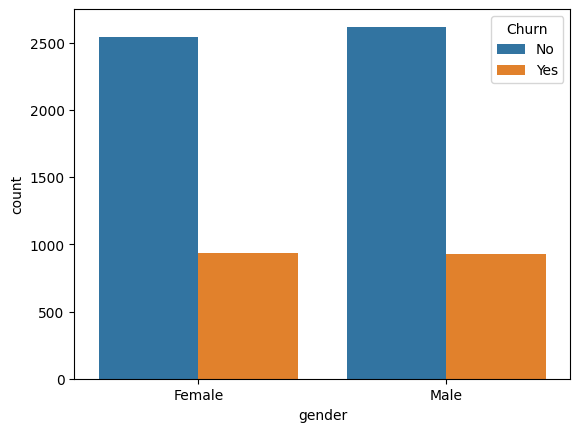

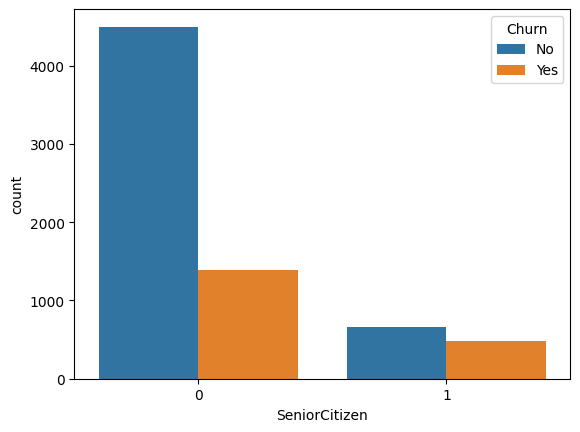

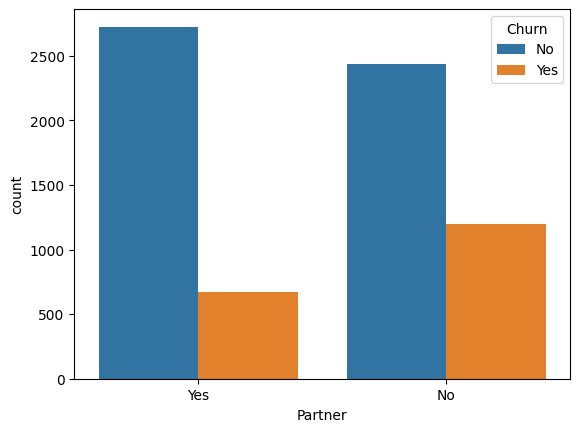

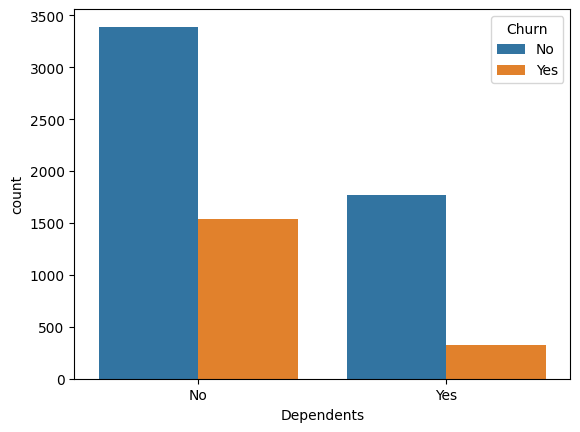

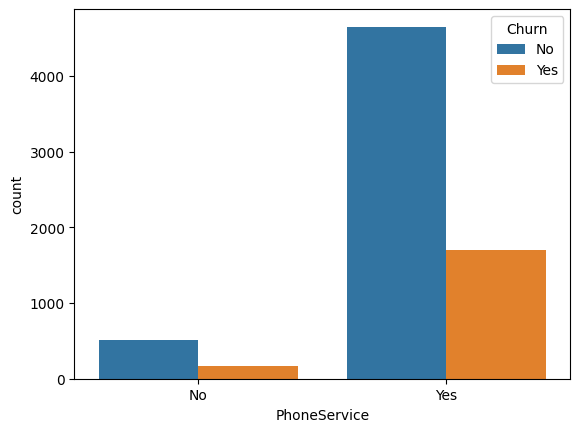

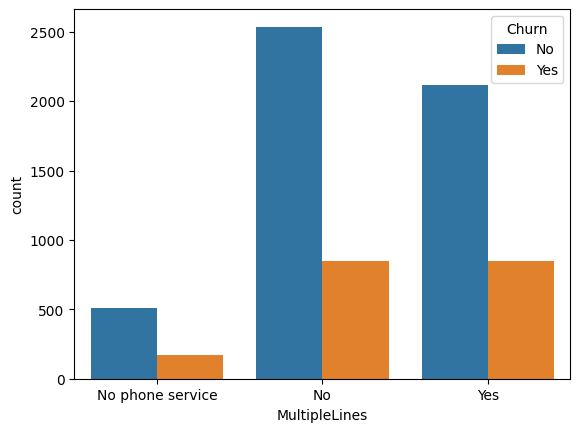

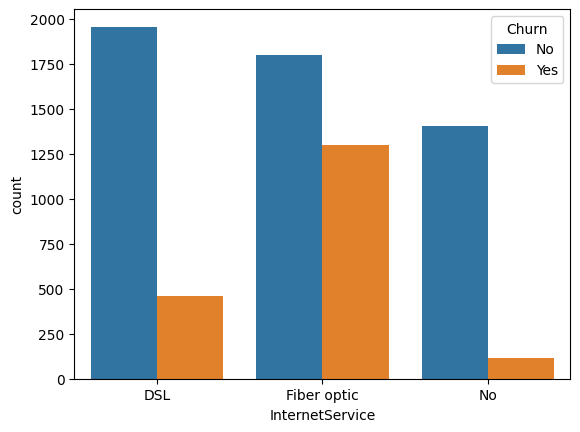

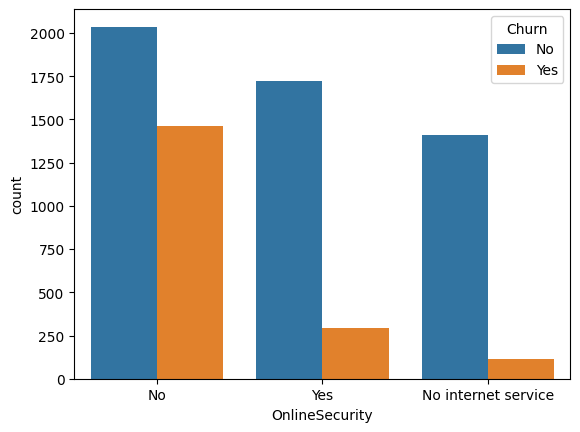

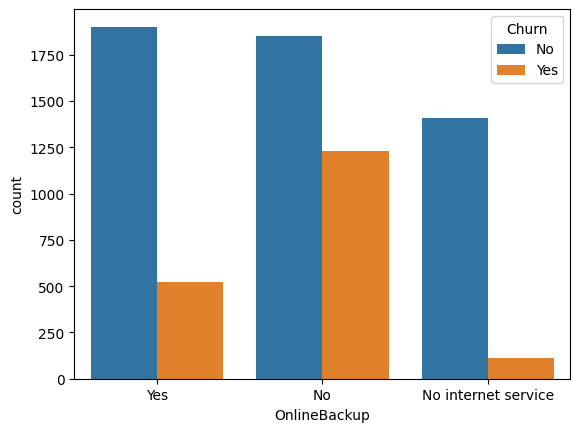

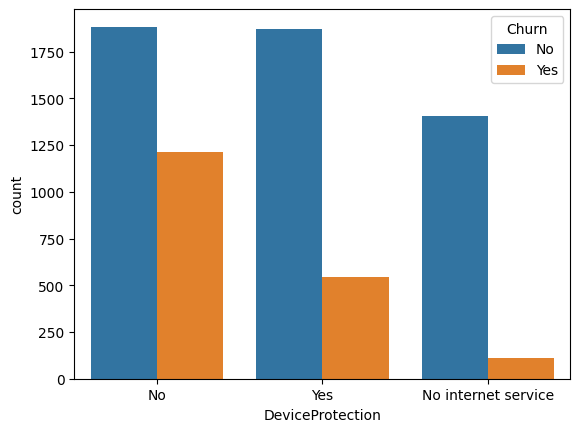

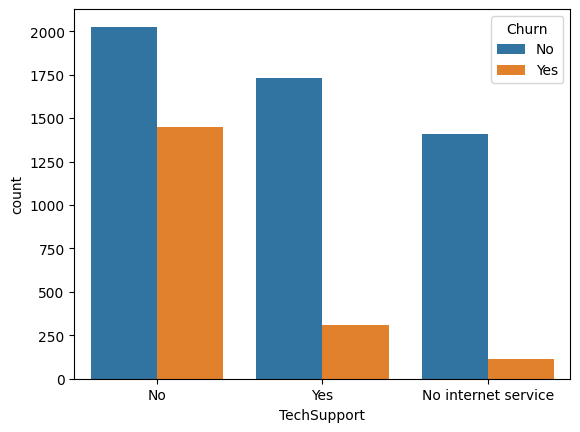

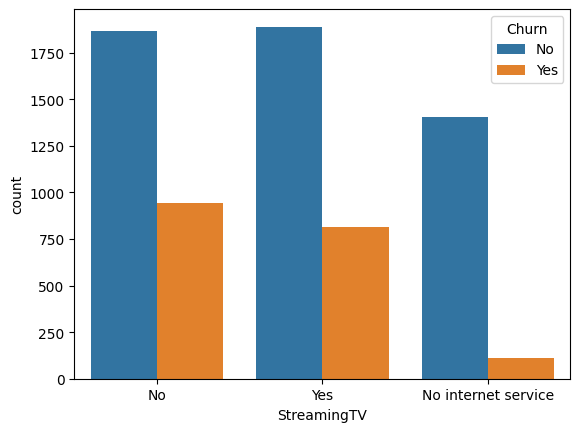

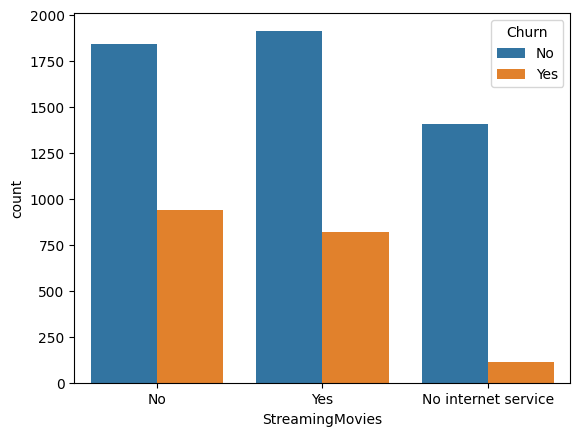

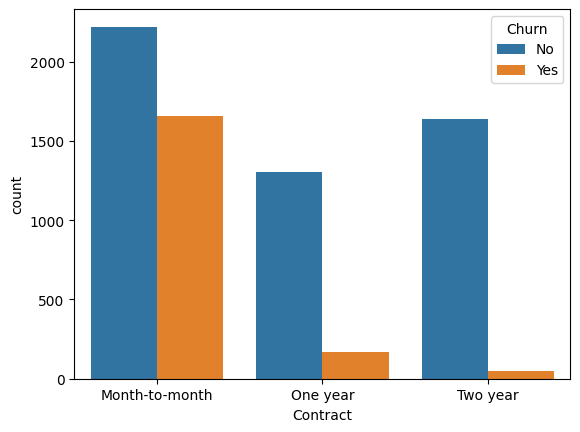

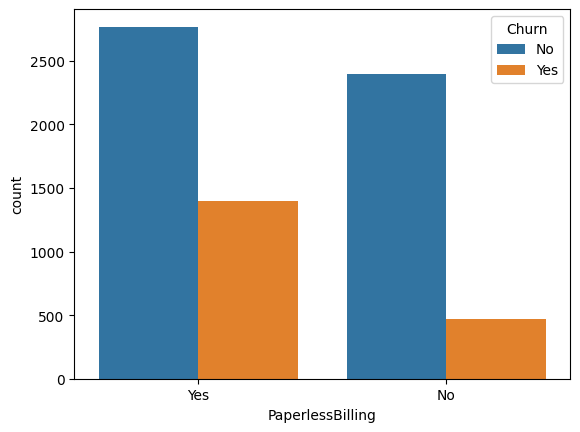

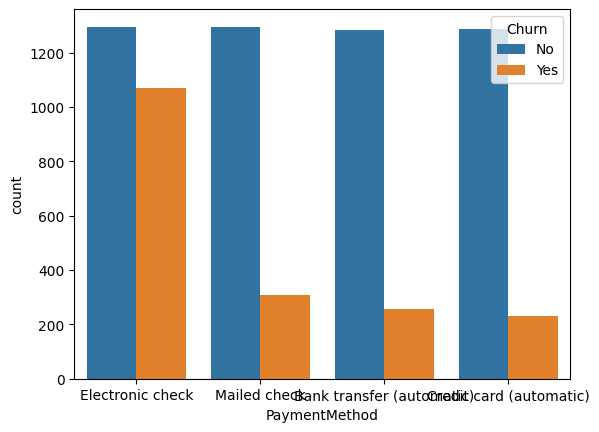

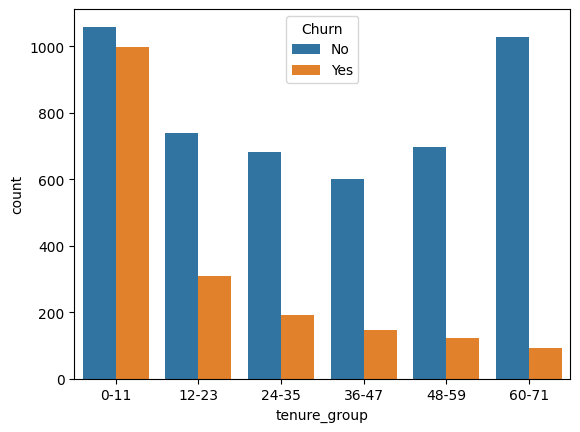

In [21]:
for i,predictor in enumerate(new_df.drop(columns = ['Churn','TotalCharges','MonthlyCharges'])):
    plt.figure(i)
    sns.countplot(data = new_df,x=predictor , hue ='Churn')

neumerical analysis

##from here doing bivariate analysis

In [22]:
new_df.gender.value_counts()

gender
Male      3549
Female    3483
Name: count, dtype: int64

In [23]:
new_df['gender'].value_counts()

gender
Male      3549
Female    3483
Name: count, dtype: int64

In [24]:
df_target0 = new_df[new_df["Churn"]=='No']
df_target1 = new_df[new_df["Churn"]=='Yes']

In [25]:
df_target1['gender'].value_counts()

gender
Female    939
Male      930
Name: count, dtype: int64

In [26]:
df_target0['gender'].value_counts()

gender
Male      2619
Female    2544
Name: count, dtype: int64

convert churn into binary value 0 and 1 from yes and no

In [27]:
new_df['Churn']=np.where(new_df.Churn=='Yes',1,0)

here the syntax numpy has is If the condition is true it returns the first value if the condition is false it returns the 2nd value That's why we're not using No

In [28]:
new_df

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0-11
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,24-35
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0-11
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,36-47
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0-11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,0,24-35
7039,Female,0,Yes,Yes,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,0,NaN
7040,Female,0,Yes,Yes,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0,0-11
7041,Male,1,Yes,No,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,1,0-11


convert all the categorical values into dummy variables

In [29]:
new_df_dummies = pd.get_dummies(new_df,dtype = int)
new_df_dummies.head()

,SeniorCitizen,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_0-11,tenure_group_12-23,tenure_group_24-35,tenure_group_36-47,tenure_group_48-59,tenure_group_60-71
0,0,29.85,29.85,0,1,0,0,1,1,0,...,0,0,1,0,1,0,0,0,0,0
1,0,56.95,1889.50,0,0,1,1,0,1,0,...,0,0,0,1,0,0,1,0,0,0
2,0,53.85,108.15,1,0,1,1,0,1,0,...,0,0,0,1,1,0,0,0,0,0
3,0,42.30,1840.75,0,0,1,1,0,1,0,...,1,0,0,0,0,0,0,1,0,0
4,0,70.70,151.65,1,1,0,1,0,1,0,...,0,0,1,0,1,0,0,0,0,0


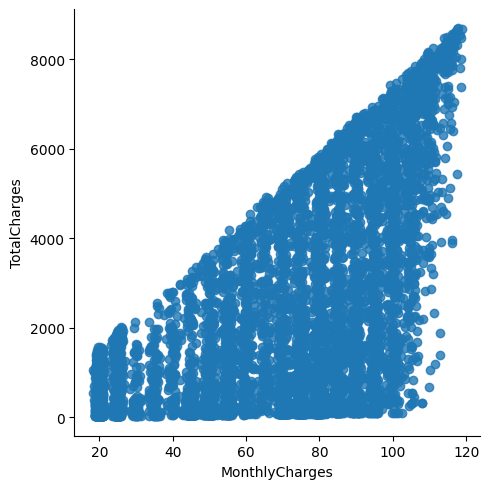

In [30]:
sns.lmplot(data = new_df_dummies,x='MonthlyCharges' , y = 'TotalCharges',fit_reg = False)

this says that Total charges increases as monthly charges increase - as expected

Text(0.5, 1.0, 'montlyCharges by churn')

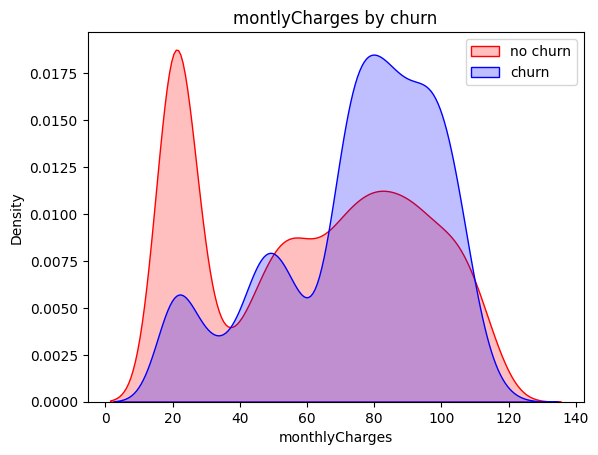

In [31]:
Mth = sns.kdeplot(
    new_df_dummies.MonthlyCharges[(new_df_dummies['Churn'] == 0)],
    color='Red',
    fill=True
)

Mth = sns.kdeplot(
    new_df_dummies.MonthlyCharges[(new_df_dummies['Churn'] == 1)],
    ax=Mth,
    color='Blue',
    fill=True
)
Mth.legend(["no churn","churn"],loc='upper right')
Mth.set_ylabel('Density')
Mth.set_xlabel('monthlyCharges')
Mth.set_title('montlyCharges by churn')



Text(0.5, 1.0, 'TotalCharges by churn')

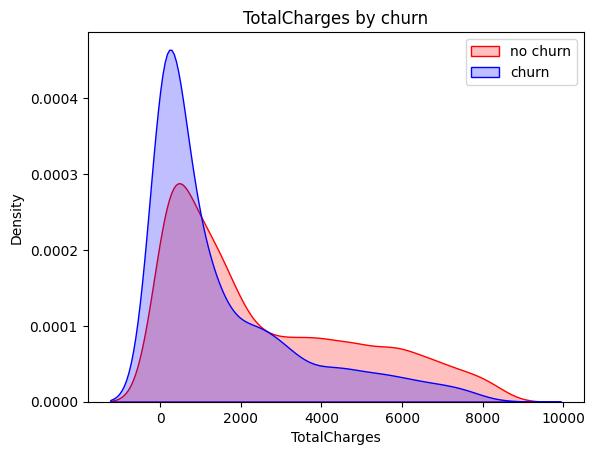

In [32]:
Mth = sns.kdeplot(
    new_df_dummies.TotalCharges[(new_df_dummies['Churn'] == 0)],
    color='Red',
    fill=True
)

Mth = sns.kdeplot(
    new_df_dummies.TotalCharges[(new_df_dummies['Churn'] == 1)],
    ax=Mth,
    color='Blue',
    fill=True
)
Mth.legend(["no churn","churn"],loc='upper right')
Mth.set_ylabel('Density')
Mth.set_xlabel('TotalCharges')
Mth.set_title('TotalCharges by churn')


This is a surprising insight that concludes higher monthly charges + low tenure + lower total charges are linked to High churn . 
That means low total charges do not necessarily mean customers are paying less They often mean customer is new when you combine monthly charges total charges and tenure the picture becomes clear 
- high monthly bill
- short time with the company
-  low accumulated total payments
-  high chance of churning

<Axes: >

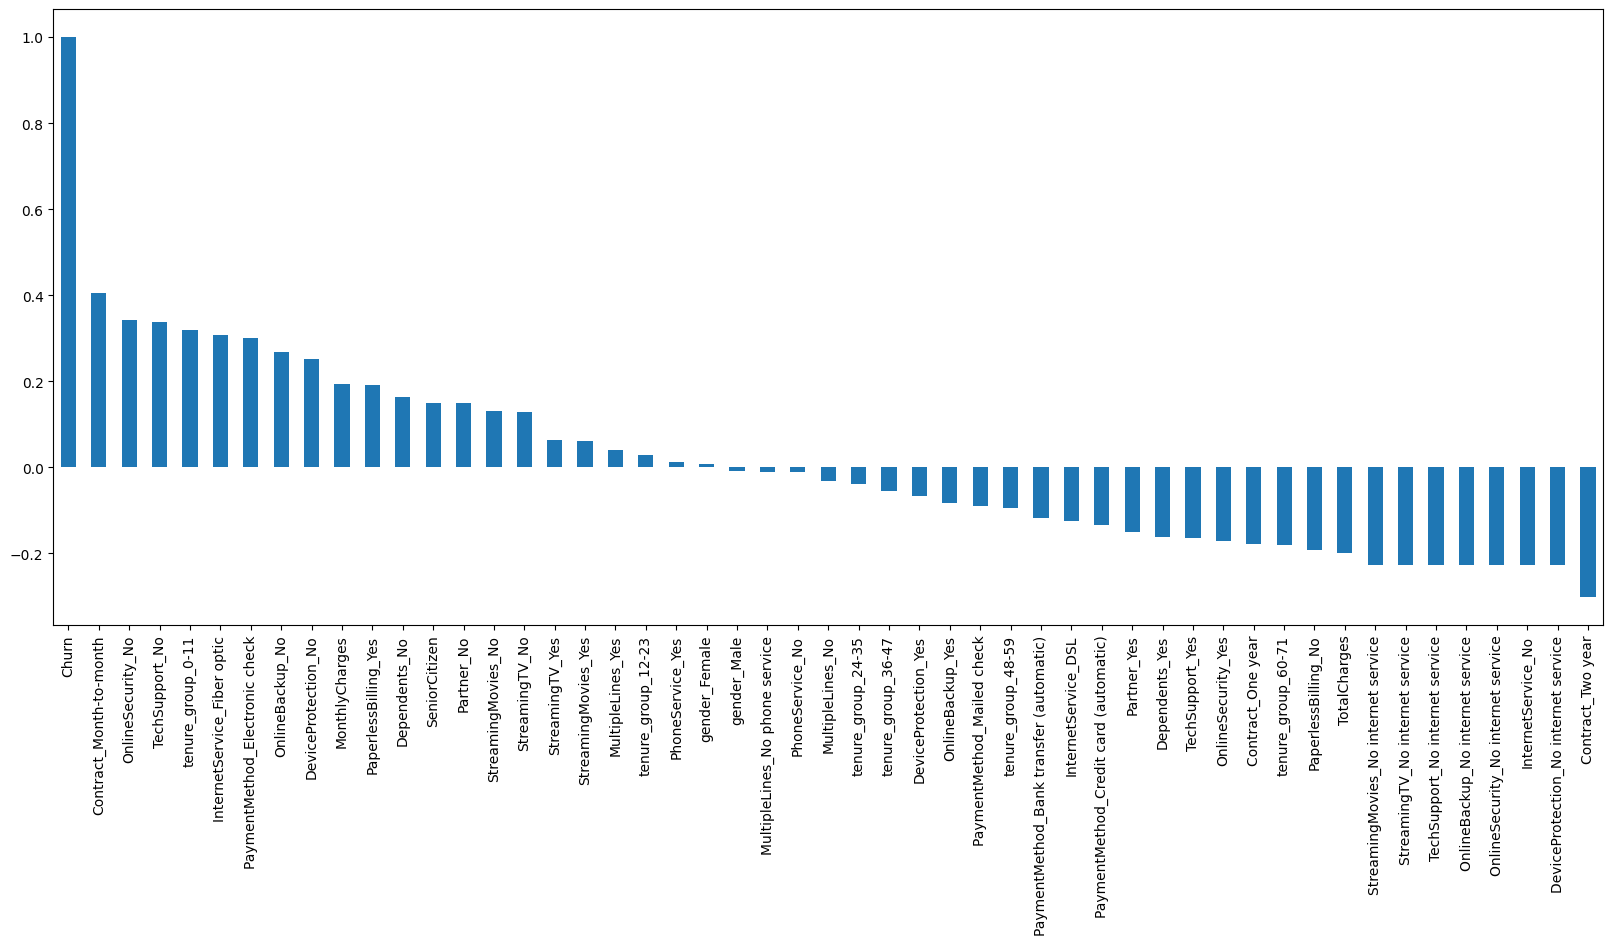

In [33]:
plt.figure(figsize=(20,8))
new_df_dummies.corr()['Churn'].sort_values(ascending = False).plot(kind='bar')

*Derived insight* 
high churn seen in case of __month to month, contracts ,no online security ,no tech support, first year of subscription and fiber optics Internet.__
    Low churn is seen in case of  __long term contract ,subscription without Internet service, and the customers engaged for 5 plus years__
Factors like gender availability of phone service and number of multiple lines have almost __no__ impact on churn

bivariate

In [34]:
len(df_target0)

5163

In [35]:
len(df_target1)

1869

In [36]:
def uniplot(df, col, title, hue=None):

    sns.set_style('whitegrid')
    sns.set_context('talk')

    plt.rcParams['axes.labelsize'] = 20
    plt.rcParams['axes.titlesize'] = 22
    plt.rcParams['axes.titlepad'] = 30

    temp = pd.Series(data=hue)

    fig, ax = plt.subplots()

    width = len(df[col].unique()) * 7 + 4 * len(temp.unique())

    fig.set_size_inches(width, 8)

    plt.xticks(rotation=45)
    
    plt.title(title)

    ax = sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index,
        hue=hue,
        palette='bright'
    )

    plt.show()

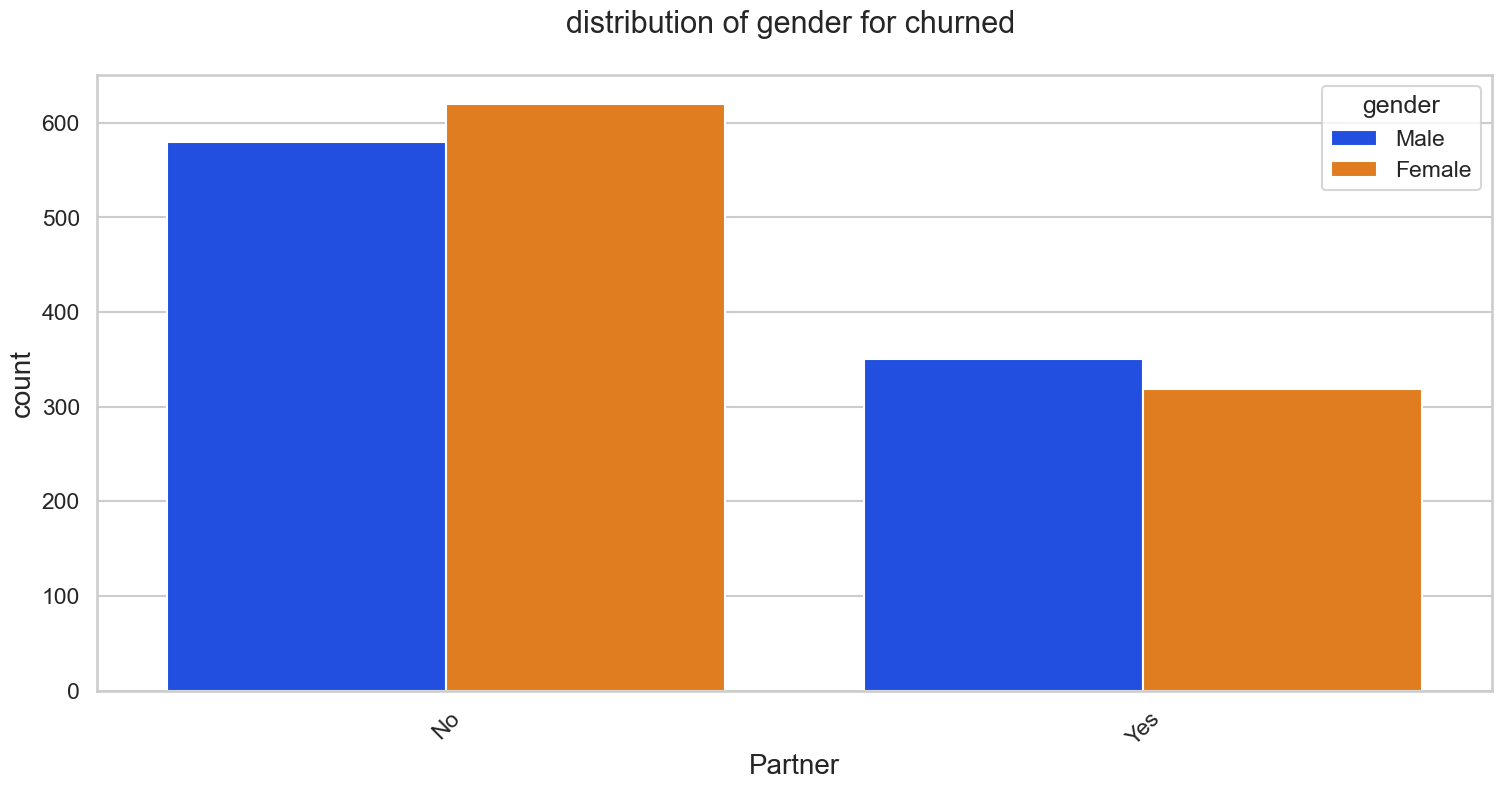

In [37]:
uniplot(df_target1,col = 'Partner' , title = 'distribution of gender for churned ', hue = 'gender')

In [38]:
df_target1['Partner'].value_counts()

Partner
No     1200
Yes     669
Name: count, dtype: int64

In [39]:
df_target1['gender'].value_counts()

gender
Female    939
Male      930
Name: count, dtype: int64

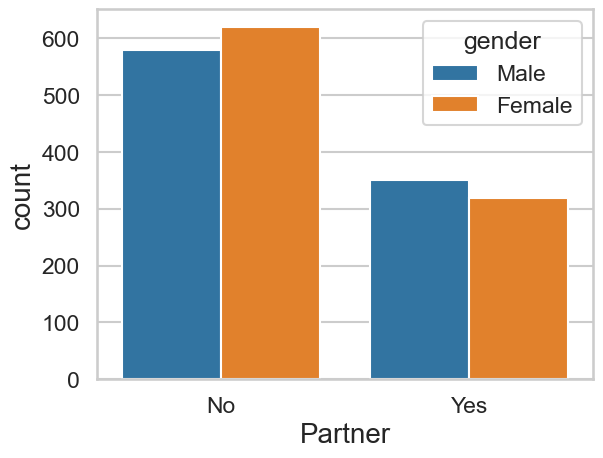

In [40]:
sns.countplot(data=df_target1, x='Partner', hue='gender')
plt.show()

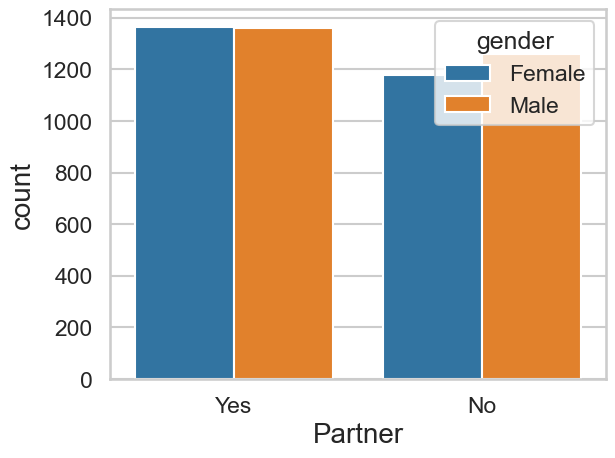

In [41]:
sns.countplot(data=df_target0, x='Partner', hue='gender')
plt.show()

In [42]:
pd.crosstab(df_target0['Partner'],df_target0['gender'])

gender,Female,Male
Partner,,
No,1180,1259
Yes,1364,1360


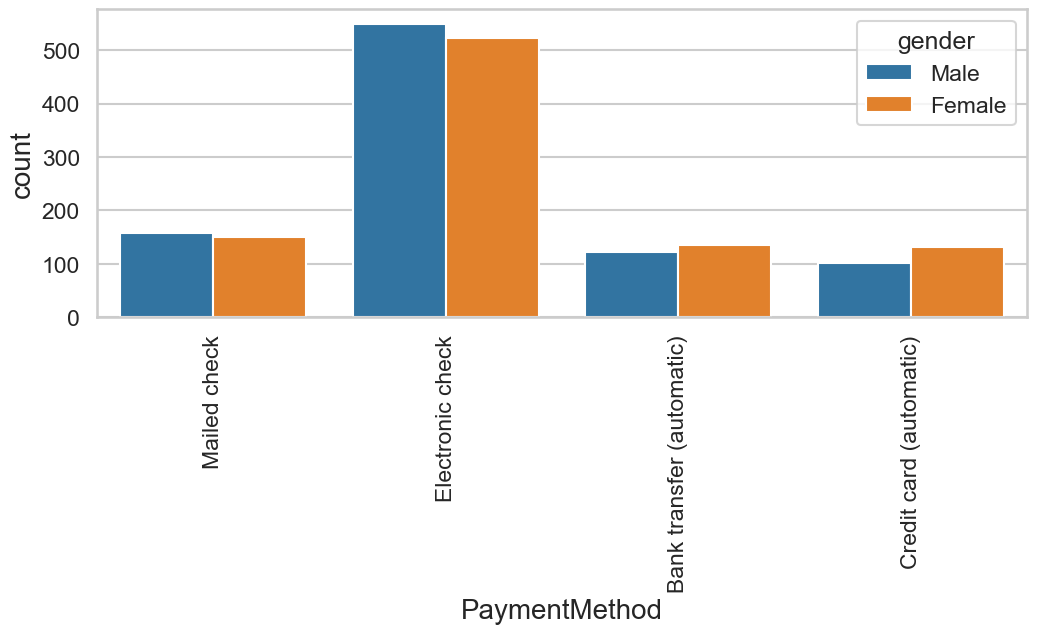

In [43]:
plt.figure(figsize = (12,4))
sns.countplot(data=df_target1, x='PaymentMethod', hue='gender')

plt.xticks(rotation = 90)
plt.show()

<Axes: xlabel='TechSupport', ylabel='count'>

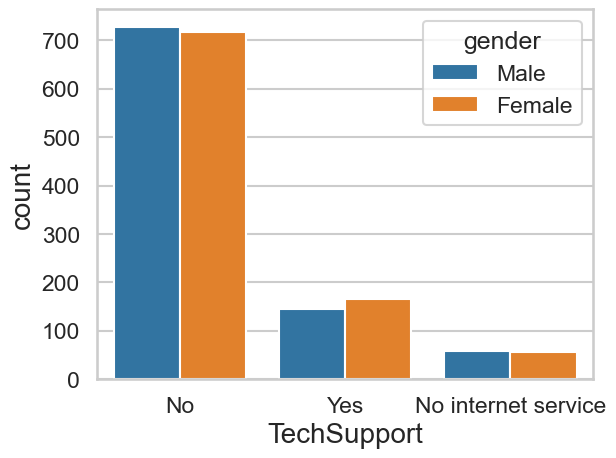

In [44]:
sns.countplot(data=df_target1, x='TechSupport', hue='gender')

So the insights are 
1. electronic check medium are highest churners
2.  contract type monthly customers are more likely to churn because of no contract terms as they are free to go customers
3.   no online security no tech support category  Are high churners
4.   Non senior citizen are high churners

In [45]:
new_df.isnull()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
7039,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
7040,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
7041,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [46]:
from ydata_profiling import ProfileReport
prof = ProfileReport(df)
prof.to_file(output_file = 'outputChurn.html')

C:\Users\ACER\AppData\Local\Temp\ipykernel_1408\3262110458.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 21/21 [00:00<00:00, 24.03it/s][A


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [49]:
new_df.to_csv("telecom_churn_cleaned.csv", index=False)

In [50]:
import os
os.getcwd()

'C:\\Users\\ACER\\project'